In [6]:
from function_lib import *

In [ ]:
def build_incidence_matrix_and_b(edges, G):
    """
    Build node–edge incidence matrix A and vector b:

        min c^T z
        s.t. A^T z = b, z >= 0

    A[v, e] = +1 if e leaves v
            = -1 if e enters v
            =  0 otherwise
    b_s = 1, b_t = -1, others 0.
    """
    nodes = list(G.nodes())
    node_index = {v: i for i, v in enumerate(nodes)}

    m = len(edges)   # number of edges
    n = len(nodes)   # number of nodes

    A = np.zeros((n, m), dtype=float)
    for e_idx, (u, v) in enumerate(edges):
        A[node_index[u], e_idx] = +1.0  # leaves u
        A[node_index[v], e_idx] = -1.0  # enters v

    s = min(nodes)
    t = max(nodes)
    b = np.zeros(n, dtype=float)
    b[node_index[s]] = +1.0
    b[node_index[t]] = -1.0

    return A, b

def compute_z_star_single(c, Z):
    """
    Compute z*(c) among enumerated feasible paths Z.
    Z : (K, m) matrix of 0/1 edges for each path.
    c : (m,) cost vector
    """
    costs = Z @ c
    k = np.argmin(costs)
    return Z[k]

def compute_z_star_batch(C, Z):
    """
    C : (N, m)
    Z : (K, m)
    returns Zstar : (N, m)
    """
    N = C.shape[0]
    Zstar = np.zeros_like(C)

    for i in range(N):
        costs = Z @ C[i]
        k = np.argmin(costs)
        Zstar[i] = Z[k]

    return Zstar

class SPOShortestPathParam:
    r"""
    Parametric SPO+ERM model for the shortest-path-style dual problem:

        Given:
            - A ∈ R^{d_c × d_p}
            - b ∈ R^{d_p}
            - dataset {x_n, c_n, z^*(c_n)}_{n=1}^N

        Solve:

            min_{B, p_n}  (1/N) ∑_{n=1}^N [
                 b^T p_n
               + 2 (B^T x_n)^T z^*(c_n)
               - c_n^T z^*(c_n)
            ]

            s.t.  A p_n ≥ c_n - 2 B^T x_n,   ∀n
                  p_n ∈ R^{d_p}
                  B   ∈ R^{d_x × d_c}

        We build the MOSEK model ONCE, with Parameters for X, C, Zstar,
        so we can reuse it for many datasets.
    """

    def __init__(self, N, d_x, d_c, d_p, A, b):
        """
        Parameters
        ----------
        N : int
            Number of samples.
        d_x : int
            Dimension of x_n.
        d_c : int
            Dimension of c_n and z^*(c_n).
        d_p : int
            Dimension of p_n.
        A : array-like, shape (d_c, d_p)
            Matrix in constraints A p_n ≥ c_n - 2 B^T x_n.
        b : array-like, shape (d_p,)
            Vector in the linear term b^T p_n.
        """
        self.N = int(N)
        self.d_x = int(d_x)
        self.d_c = int(d_c)
        self.d_p = int(d_p)

        # Check and store A
        A = np.asarray(A, dtype=float)
        if A.shape != (self.d_c, self.d_p):
            raise ValueError(f"A must have shape ({self.d_c}, {self.d_p})")
        self.A = A

        # Check and store b
        b = np.asarray(b, dtype=float).reshape(-1)
        if b.shape[0] != self.d_p:
            raise ValueError(f"b must have length d_p = {self.d_p}")
        self.b = b

        # Build MOSEK model with Parameters X, C, Zstar
        self._build_model()

    # ------------------------------------------------------------------
    # INTERNAL: build MOSEK model with Parameters
    # ------------------------------------------------------------------
    def _build_model(self):
        M = Model("spo_sp_param")
        self.M = M

        # ---------------- Parameters ----------------
        # X: (N, d_x)
        self.Xpar = M.parameter("X", [self.N, self.d_x])
        # C: (N, d_c)
        self.Cpar = M.parameter("C", [self.N, self.d_c])
        # Zstar: (N, d_c) where each row is z^*(c_n)^T
        self.Zstarpar = M.parameter("Zstar", [self.N, self.d_c])

        # ---------------- Variables -----------------
        # B: (d_x, d_c)
        self.B = M.variable("B", [self.d_x, self.d_c], Domain.unbounded())
        # p_n: (N, d_p)
        self.P = M.variable("p", [self.N, self.d_p], Domain.unbounded())

        # ---------------- Expressions ----------------
        # XB = X B  (N × d_x) @ (d_x × d_c) -> (N × d_c)
        # Each row is x_n^T B = (B^T x_n)^T.
        self.XB = Expr.mul(self.Xpar, self.B)  # shape (N, d_c)

        # For constraints: A p_n ≥ c_n - 2 B^T x_n
        # Using P A^T: (N × d_p) @ (d_p × d_c) -> (N × d_c)
        A_T = Matrix.dense(self.A.T)
        AP = Expr.mul(self.P, A_T)  # shape (N, d_c)

        # Constraint: A p_n - (c_n - 2 B^T x_n) ≥ 0
        # => AP - C + 2 XB ≥ 0
        dual_residual = Expr.add(
            Expr.sub(AP, self.Cpar),          # AP - C
            Expr.mul(2.0, self.XB)           # + 2 XB
        )
        M.constraint("dual_feas", dual_residual, Domain.greaterThan(0.0))

        # ---------------- Objective ------------------
        # term1 = ∑_n b^T p_n
        # replicate b across rows
        b_row = self.b.reshape(1, self.d_p)           # (1, d_p)
        b_mat = np.tile(b_row, (self.N, 1))           # (N, d_p)
        b_mat_dense = Matrix.dense(b_mat)
        term1 = Expr.sum(Expr.mulElm(self.P, b_mat_dense))

        # term2 = ∑_n (B^T x_n)^T z^*(c_n) = ∑_n ∑_k (XB_{n,k} * Zstar_{n,k})
        XB_times_Z = Expr.mulElm(self.XB, self.Zstarpar)  # (N, d_c)
        term2_per_n = Expr.sum(XB_times_Z, 1)             # (N,)
        term2 = Expr.sum(term2_per_n)

        # term3 = ∑_n c_n^T z^*(c_n) = ∑_n ∑_k C_{n,k} * Zstar_{n,k}
        CZ = Expr.mulElm(self.Cpar, self.Zstarpar)        # (N, d_c)
        term3_per_n = Expr.sum(CZ, 1)                     # (N,)
        term3 = Expr.sum(term3_per_n)

        # Full objective: (1/N) [ term1 + 2 term2 - term3 ]
        obj_expr = Expr.sub(
            Expr.add(term1, Expr.mul(2.0, term2)),
            term3
        )
        obj = Expr.mul(1.0 / self.N, obj_expr)

        M.objective("spo_sp_obj", ObjectiveSense.Minimize, obj)

    # ------------------------------------------------------------------
    # PUBLIC: solve for a given dataset (X, C, Zstar)
    # ------------------------------------------------------------------
    def solve(self, X, C, Zstar, verbose: bool = False):
        """
        Solve the SPO+SP problem for a given dataset (X, C, Zstar).

        Parameters
        ----------
        X : array, shape (N, d_x)
            Feature matrix (rows = x_n^T).
        C : array, shape (N, d_c)
            Cost matrix (rows = c_n^T).
        Zstar : array, shape (N, d_c)
            Each row is z^*(c_n)^T, i.e., the optimal shortest-path solution
            (or more generally the LP solution) for cost c_n.
        verbose : bool
            If True, show MOSEK log.

        Returns
        -------
        result : dict with keys:
            "B"   : optimal B, shape (d_x, d_c)
            "P"   : optimal p_n, shape (N, d_p)
            "obj" : optimal objective value
        """
        X = np.asarray(X, dtype=float)
        C = np.asarray(C, dtype=float)
        Zstar = np.asarray(Zstar, dtype=float)

        # Shape checks
        if X.shape != (self.N, self.d_x):
            raise ValueError(f"X must have shape ({self.N}, {self.d_x})")
        if C.shape != (self.N, self.d_c):
            raise ValueError(f"C must have shape ({self.N}, {self.d_c})")
        if Zstar.shape != (self.N, self.d_c):
            raise ValueError(f"Zstar must have shape ({self.N}, {self.d_c})")

        # Set parameter values
        self.Xpar.setValue(X)
        self.Cpar.setValue(C)
        self.Zstarpar.setValue(Zstar)

        # Logging
        if verbose:
            self.M.setLogHandler(sys.stdout)
        else:
            self.M.setLogHandler(None)

        # Solve
        self.M.solve()

        # Extract solution
        B_val = np.array(self.B.level()).reshape(self.d_x, self.d_c)
        P_val = np.array(self.P.level()).reshape(self.N, self.d_p)
        obj_val = self.M.primalObjValue()

        return {
            "B": B_val,
            "P": P_val,
            "obj": obj_val,
        }
    
    # ------------------------------------------------------------------
    # PUBLIC: evaluate regret on a test set
    # ------------------------------------------------------------------
    def evaluate_regret(self, X_test, C_test, Z, B=None, return_per_sample=False):
        """
        Evaluate prediction regret on a test dataset (X_test, C_test),
        given a discrete feasible set Z of s-t paths (0/1 edge indicators).

        Parameters
        ----------
        X_test : array, shape (N_test, d_x)
        C_test : array, shape (N_test, d_c)
        Z      : array, shape (K, d_c)
            All feasible solutions (paths) as rows.
        B : array or None, optional
            If None, use the current model solution self.B.
            Otherwise, use this B matrix (d_x, d_c) for evaluation.
        return_per_sample : bool, optional
            If True, also return regret per sample.

        Returns
        -------
        result : dict with keys:
            "avg_regret" : scalar
            "regret_per_sample" : (N_test,) array (if return_per_sample)
        """
        # 1. Setup and validations
        X_test = np.asarray(X_test, dtype=float)
        C_test = np.asarray(C_test, dtype=float)
        Z = np.asarray(Z, dtype=float)

        N_test, d_x_test = X_test.shape
        N_ctest, d_c_test = C_test.shape
        K, d_c_Z = Z.shape

        if d_x_test != self.d_x:
            raise ValueError(f"X_test shape mismatch: expected dim {self.d_x}, got {d_x_test}")
        if d_c_test != self.d_c:
            raise ValueError(f"C_test shape mismatch: expected dim {self.d_c}, got {d_c_test}")
        if d_c_Z != self.d_c:
            raise ValueError(f"Z dimension mismatch: expected {self.d_c}, got {d_c_Z}")
        if N_test != N_ctest:
            raise ValueError("X_test and C_test must have the same number of rows.")

        # Get B: from argument or current model solution
        if B is None:
            B = np.array(self.B.level()).reshape(self.d_x, self.d_c)
        else:
            B = np.asarray(B, dtype=float).reshape(self.d_x, self.d_c)

        # 2. Vectorized calculation

        # A. Predict costs for all samples
        #    C_hat = X_test B  (N_test, d_c)
        C_hat = X_test @ B

        # B. Objective values for all feasible z under predicted costs
        #    obj_pred[i, k] = (C_hat[i] dot Z[k])
        obj_pred = C_hat @ Z.T  # (N_test, K)

        # C. Index of predicted optimal solution for each sample
        idx_hat = np.argmin(obj_pred, axis=1)  # (N_test,)

        # D. True objective values for all feasible z
        obj_true = C_test @ Z.T  # (N_test, K)

        # E. True cost of the decision we predicted
        chosen_costs = obj_true[np.arange(N_test), idx_hat]

        # F. True cost of the optimal decision (oracle)
        optimal_costs = obj_true.min(axis=1)

        # G. Regret
        # regrets = chosen_costs - optimal_costs

        regrets = (chosen_costs - optimal_costs)/optimal_costs

        avg_regret = float(regrets.mean())

        result = {"avg_regret": avg_regret}
        if return_per_sample:
            result["regret_per_sample"] = regrets

        return result

In [ ]:
n_instance   = 100
input_dim    = 3
noise        = 0.5
deg          = 2
grid_width   = 3
n_simulation = 30

# ----------------- paths ------------------
base_path = change_to_py_file_dir()
base      = os.path.join(base_path, "Data", "Shortest_path")

# ----------------- results ----------------
total_result  = {}

# =========================================================
# Build Z (all feasible z), graph G, and incidence A, b once
# =========================================================
sols, edges, G = generate_all_feasible_solutions(grid_width=grid_width)
Z = np.vstack(sols)  # (K, m), m = number of edges = d_c

A, b = build_incidence_matrix_and_b(edges, G)
d_c = Z.shape[1]           # number of edges
d_p = len(G.nodes())       # number of nodes

model_list = ["SPO"]

for model_type in model_list:

    regret_result = []
    parame_result = []

    solver = None  # will build once on the first iteration

    for seed in tqdm(range(n_simulation),
                     desc="Running simulations",
                     colour="green"):

        # ---- reproducibility ----
        random.seed(seed)
        np.random.seed(seed)

        # ---- data for this seed ----
        # y_* are cost vectors over edges, aligned with `edges` and thus Z
        x_train, y_train, x_test, y_test = load_shortest_path_setting_with_splits(
            base, n_instance, input_dim, deg, noise, grid_width, seed
        )

        # ---- build solver only once (reuse the same MOSEK model) ----
        if solver is None:
            # Make sure this import matches where your class is defined
            # from your_module import SPOShortestPathParam
            solver = SPOShortestPathParam(
                N=x_train.shape[0],      # number of training samples (fixed)
                d_x=x_train.shape[1],    # feature dim
                d_c=y_train.shape[1],    # cost dim (should equal number of edges)
                d_p=d_p,                 # number of dual vars (nodes)
                A=A.T,
                b=b
            )

        # ---- compute z_star for training data (primal optimal flows) ----
        Zstar_train = compute_z_star_batch(y_train, Z)  # (N_train, d_c)

        # ---- solve training problem for this seed ----
        res = solver.solve(x_train, y_train, Zstar_train, verbose=False)

        # ---- evaluate regret on test set using class method ----
        eval_res = solver.evaluate_regret(
            X_test=x_test,
            C_test=y_test,
            Z=Z,
            return_per_sample=False
        )

        regret_result.append(eval_res["avg_regret"])
        parame_result.append(res["B"])

    # save results for this model type
    total_result[model_type] = {
        "regret": regret_result,
        "params": parame_result
    }

    # ==================================================
    # Clean up memory before next model!
    # ==================================================
    if solver is not None:
        solver.M.dispose()  # Release Mosek C-memory immediately
        del solver          # Delete Python object

    gc.collect()            # Force Python Garbage Collector

    process = psutil.Process(os.getpid())
    print(f"Python process RAM: {process.memory_info().rss/1024/1024/1024:.3f} GB")

# Save the result to pickle file
save_path = os.path.join(base_path, "Results", "Score")
os.makedirs(save_path, exist_ok=True)   # create directory if not exist
file_path = os.path.join(
    save_path,
    f"Shortest_path_spo_result_{n_instance}_{input_dim}_{deg}_{noise}_{grid_width}.pkl"
)
with open(file_path, "wb") as f:
    pickle.dump(total_result, f)

def print_memory():
    mem = psutil.virtual_memory()
    print(f"Available: {mem.available/1024/1024/1024:.2f} GB")
    print(f"Used:      {(mem.total - mem.available)/1024/1024/1024:.2f} GB")
    print(f"Percent:   {mem.percent}%")

print_memory()

Running simulations:   0%|          | 0/30 [00:00<?, ?it/s]

Problem
  Name                   : spo_sp_param    
  Objective sense        : minimize        
  Type                   : LO (linear optimization problem)
  Constraints            : 1080            
  Affine conic cons.     : 0               
  Disjunctive cons.      : 0               
  Cones                  : 0               
  Scalar variables       : 847             
  Matrix variables       : 0               
  Integer variables      : 0               

Optimizer started.
Presolve started.
Linear dependency checker started.
Linear dependency checker terminated.
Eliminator started.
Freed constraints in eliminator : 720
Eliminator terminated.
Eliminator started.
Freed constraints in eliminator : 0
Eliminator terminated.
Eliminator - tries                  : 2                 time                   : 0.00            
Lin. dep.  - tries                  : 1                 time                   : 0.00            
Lin. dep.  - primal attempts        : 1                 successes    

Running simulations:  17%|█▋        | 5/30 [00:00<00:00, 45.73it/s]

Problem
  Name                   : spo_sp_param    
  Objective sense        : minimize        
  Type                   : LO (linear optimization problem)
  Constraints            : 1080            
  Affine conic cons.     : 0               
  Disjunctive cons.      : 0               
  Cones                  : 0               
  Scalar variables       : 847             
  Matrix variables       : 0               
  Integer variables      : 0               

Optimizer started.
Optimizer terminated. Time: 0.01    


Interior-point solution summary
  Problem status  : PRIMAL_AND_DUAL_FEASIBLE
  Solution status : OPTIMAL
  Primal.  obj: 7.5251027259e+00    nrm: 5e+01    Viol.  con: 3e-08    var: 0e+00  
  Dual.    obj: 7.5251027215e+00    nrm: 8e+00    Viol.  con: 5e-10    var: 3e-10  

Basic solution summary
  Problem status  : PRIMAL_AND_DUAL_FEASIBLE
  Solution status : OPTIMAL
  Primal.  obj: 7.5251026137e+00    nrm: 6e+01    Viol.  con: 1e-14    var: 0e+00  
  Dual.    obj: 7.52510

Running simulations:  37%|███▋      | 11/30 [00:00<00:00, 53.71it/s]

...

Running simulations:  83%|████████▎ | 25/30 [00:00<00:00, 62.48it/s]

Problem
  Name                   : spo_sp_param    
  Objective sense        : minimize        
  Type                   : LO (linear optimization problem)
  Constraints            : 1080            
  Affine conic cons.     : 0               
  Disjunctive cons.      : 0               
  Cones                  : 0               
  Scalar variables       : 847             
  Matrix variables       : 0               
  Integer variables      : 0               

Optimizer started.
Optimizer terminated. Time: 0.01    


Interior-point solution summary
  Problem status  : PRIMAL_AND_DUAL_FEASIBLE
  Solution status : OPTIMAL
  Primal.  obj: 9.1472394011e+00    nrm: 5e+01    Viol.  con: 4e-09    var: 0e+00  
  Dual.    obj: 9.1472394005e+00    nrm: 9e+00    Viol.  con: 7e-11    var: 6e-11  

Basic solution summary
  Problem status  : PRIMAL_AND_DUAL_FEASIBLE
  Solution status : OPTIMAL
  Primal.  obj: 9.1472393870e+00    nrm: 5e+01    Viol.  con: 1e-14    var: 0e+00  
  Dual.    obj: 9.14723

Running simulations: 100%|██████████| 30/30 [00:00<00:00, 60.39it/s]

Python process RAM: 0.201 GB


Available: 16.05 GB
Used:      15.70 GB
Percent:   49.4%


Model     Mean      Std    VaR90   CVaR90
  SPO 0.097341 0.050409 0.165579 0.202519


C:\Users\zhaoz\AppData\Local\Temp\ipykernel_23296\3750364867.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


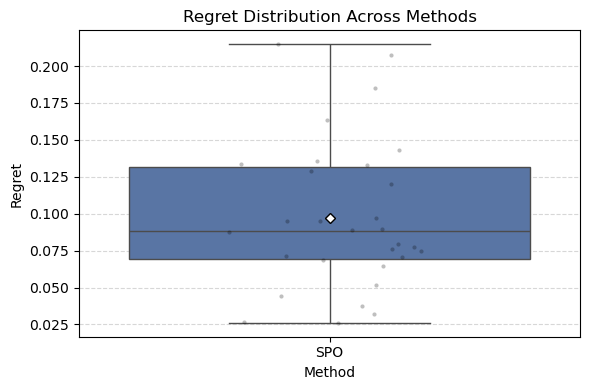

In [ ]:
# Compute stats for the LST model
# regrets = total_result["LST-0.1"]["regret"]

# mean, std, var90, cvar90 = compute_stats(regrets)

# print(f"Mean    : {mean:.6f}")
# print(f"Std     : {std:.6f}")
# print(f"VaR 90  : {var90:.6f}")
# print(f"CVaR 90 : {cvar90:.6f}")
rows = []
for model_type in model_list:
    regrets = total_result[model_type]["regret"]
    mean, std, var90, cvar90 = compute_stats(regrets)

    rows.append({
        "Model": model_type,
        "Mean": mean,
        "Std": std,
        "VaR90": var90,
        "CVaR90": cvar90
    })


# convert to DataFrame
df = pd.DataFrame(rows)

# nicely formatted print
print(df.to_string(index=False, float_format="%.6f"))


# Collect regret distributions across all model types
df_list = []
for model_type, data in total_result.items():
    df_list.append(pd.DataFrame({
        "method": [model_type] * len(data["regret"]),
        "regret": data["regret"]
    }))

df = pd.concat(df_list, ignore_index=True)

# Academic color palette
palette = sns.color_palette("deep")
unique_methods = sorted(df["method"].unique())
method_colors = {m: palette[i % len(palette)] for i, m in enumerate(unique_methods)}

plt.figure(figsize=(6, 4))

sns.boxplot(
    data=df,
    x="method",
    y="regret",
    palette=method_colors,
    showmeans=True,
    meanprops={
        "marker": "D",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": 5
    }
)

sns.stripplot(
    data=df,
    x="method",
    y="regret",
    color="black",
    alpha=0.25,
    jitter=0.2,
    size=3
)

plt.title("Regret Distribution Across Methods", fontsize=12)
plt.ylabel("Regret")
plt.xlabel("Method")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()

# Save figure
save_dir = os.path.join(base_path, "Results", "Figures")
os.makedirs(save_dir, exist_ok=True)

plt.savefig(
    os.path.join(save_dir, "spo_regret_comparison.png"),
    dpi=400,
    bbox_inches="tight"
)

plt.show()

In [10]:
# seed = 1
# x_train, y_train, x_test, y_test = load_shortest_path_setting_with_splits(base, n_instance, input_dim, deg, noise, grid_width, seed)

# # Example usage:

# sols, edges, G = generate_all_feasible_solutions(grid_width=5)
# print("Number of edges:", len(edges))
# print("Number of feasible s->t paths:", len(sols))
# print("First solution vector:", sols[0])

# # pick any solution
# vec = sols[10]
# # draw
# draw_solution(G, edges, vec, grid_width=5, cost=y_train[0])
# solver = LSTECPParam(
#     N=x_train.shape[0],
#     d_x=x_train.shape[1],
#     d_c=y_train.shape[1],
#     Z=sols,
#     eta=0.5
# )

# X_run = x_train   # shape (N, d_x)
# C_run = y_train   # shape (N, d_c)

# res = solver.solve(X_run, C_run, verbose=False)
# eval_res = solver.evaluate_regret(x_test, y_test, return_per_sample=True)
# print("Avg regret:", eval_res["avg_regret"])
# # print("Per-sample regret:", eval_res["regret_per_sample"])
